In [1]:
!pip install -q --upgrade wandb

import os
import torch
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import wandb
import random

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"] = user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 67.4 MB/s eta 0:00:00:00:0100:01
Device: cuda


In [2]:
config = {
    "data_dir": Path("/kaggle/input/competitions/jaguar-re-id"),
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size": 384,
    "val_split": 0.2,
    "seed": SEED,
}

# Load data
train_df = pd.read_csv(config["data_dir"] / "train.csv")
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']
)

print(f"Total images: {len(train_df)}")
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Classes: {num_classes}")

Total images: 1895
Train: 1516 | Val: 379 | Classes: 31


In [3]:
preprocess = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32, desc="Extracting"):
    model.eval()
    embeddings = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i+batch_size]
        tensors = []
        for p in batch_paths:
            try:
                img = Image.open(p).convert("RGB")
                tensors.append(preprocess(img))
            except:
                tensors.append(torch.zeros(3, config["input_size"],
                                           config["input_size"]))
        batch = torch.stack(tensors).to(device)
        embeddings.append(model(batch).cpu().numpy())
    return np.vstack(embeddings)


print("Loading MegaDescriptor...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"], pretrained=True)
megadescriptor.eval()
megadescriptor.to(device)

with torch.no_grad():
    dummy = torch.randn(1, 3, config["input_size"],
                        config["input_size"]).to(device)
    megadescriptor_dim = megadescriptor(dummy).shape[1]

print(f"MegaDescriptor loaded | Dim: {megadescriptor_dim}")

cache_dir = Path("embeddings")
cache_dir.mkdir(exist_ok=True)
full_cache = cache_dir / "full_embeddings.npz"

if full_cache.exists():
    full_embeddings = np.load(full_cache)["embeddings"]
    print(f"Loaded cached embeddings: {full_embeddings.shape}")
else:
    print("Extracting embeddings for full dataset...")
    all_paths = [config["data_dir"] / "train/train" / f
                 for f in train_df['filename'].values]
    full_embeddings = extract_embeddings(megadescriptor, all_paths,
                                         desc="Full dataset")
    np.savez_compressed(full_cache, embeddings=full_embeddings)
    print(f"Saved: {full_embeddings.shape}")

Loading MegaDescriptor...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

MegaDescriptor loaded | Dim: 1536
Extracting embeddings for full dataset...


Full dataset:   0%|          | 0/60 [00:00<?, ?it/s]

Saved: (1895, 1536)


In [4]:
# Normalize embeddings
norms = np.linalg.norm(full_embeddings, axis=1, keepdims=True)
normalized_embeddings = full_embeddings / norms

# Compute full similarity matrix
print("Computing similarity matrix...")
sim_matrix = normalized_embeddings @ normalized_embeddings.T
np.fill_diagonal(sim_matrix, 0)  # exclude self-similarity

all_filenames = train_df['filename'].values
all_labels = train_df['ground_truth'].values
all_splits = ['train' if f in set(train_data['filename'].values) 
              else 'val' for f in all_filenames]

# Find near-duplicate pairs at different thresholds
thresholds = [0.99, 0.98, 0.97, 0.95]

print("\nNear-duplicate counts at different thresholds:")
print(f"{'Threshold':<12} {'Total Pairs':<14} {'Same Identity':<16} {'Cross Identity':<16} {'Cross Split':<12}")
print("-" * 70)

threshold_results = []
for thresh in thresholds:
    pairs = []
    rows, cols = np.where(sim_matrix > thresh)
    # Only keep upper triangle to avoid duplicates
    for r, c in zip(rows, cols):
        if r < c:
            pairs.append({
                "img1": all_filenames[r],
                "img2": all_filenames[c],
                "similarity": float(sim_matrix[r, c]),
                "label1": all_labels[r],
                "label2": all_labels[c],
                "split1": all_splits[r],
                "split2": all_splits[c],
                "same_identity": all_labels[r] == all_labels[c],
                "cross_split": all_splits[r] != all_splits[c],
            })
    
    same_id = sum(1 for p in pairs if p["same_identity"])
    cross_id = sum(1 for p in pairs if not p["same_identity"])
    cross_split = sum(1 for p in pairs if p["cross_split"])
    
    print(f"{thresh:<12} {len(pairs):<14} {same_id:<16} {cross_id:<16} {cross_split:<12}")
    threshold_results.append({
        "threshold": thresh,
        "total_pairs": len(pairs),
        "same_identity": same_id,
        "cross_identity": cross_id,
        "cross_split": cross_split,
    })

# Use 0.99 threshold for detailed analysis
thresh = 0.99
rows, cols = np.where(sim_matrix > thresh)
pairs_99 = []
for r, c in zip(rows, cols):
    if r < c:
        pairs_99.append({
            "img1": all_filenames[r],
            "img2": all_filenames[c],
            "similarity": float(sim_matrix[r, c]),
            "label1": all_labels[r],
            "label2": all_labels[c],
            "split1": all_splits[r],
            "split2": all_splits[c],
            "same_identity": all_labels[r] == all_labels[c],
            "cross_split": all_splits[r] != all_splits[c],
        })

pairs_df = pd.DataFrame(pairs_99).sort_values("similarity", ascending=False)
print(f"\nDetailed analysis at threshold 0.99:")
print(f"Total near-duplicate pairs: {len(pairs_df)}")
print(f"Same identity pairs: {len(pairs_df[pairs_df['same_identity']])}")
print(f"Cross identity pairs: {len(pairs_df[~pairs_df['same_identity']])}")
print(f"Cross split pairs (train/val leak): {len(pairs_df[pairs_df['cross_split']])}")

if len(pairs_df) > 0:
    print(f"\nTop 10 most similar pairs:")
    print(pairs_df[['img1', 'img2', 'similarity', 
                     'label1', 'label2', 'same_identity',
                     'cross_split']].head(10).to_string(index=False))

Computing similarity matrix...

Near-duplicate counts at different thresholds:
Threshold    Total Pairs    Same Identity    Cross Identity   Cross Split 
----------------------------------------------------------------------
0.99         317            317              0                86          
0.98         755            754              1                223         
0.97         1225           1188             37               397         
0.95         1993           1901             92               661         

Detailed analysis at threshold 0.99:
Total near-duplicate pairs: 317
Same identity pairs: 317
Cross identity pairs: 0
Cross split pairs (train/val leak): 86

Top 10 most similar pairs:
          img1           img2  similarity label1 label2  same_identity  cross_split
train_1854.png train_1855.png    0.999350  Tomas  Tomas           True        False
train_1867.png train_1868.png    0.999272  Tomas  Tomas           True        False
train_1849.png train_1850.png    0.99

Per-identity near-duplicate analysis (threshold=0.99):
identity  total_images  duplicate_pairs  cross_split_pairs  duplicate_rate
   Tomas            63              163                 32            2.59
Kamaikua           105               35                 12            0.33
  Benita            86               26                 11            0.30
 Medrosa           170               19                  5            0.11
     Lua           120               14                  5            0.12
 Guaraci            31               14                  3            0.45
  Ousado           179               13                  7            0.07
   Kwang           113                8                  4            0.07
  Saseka            79                4                  3            0.05
   Bagua            60                4                  0            0.07
 Marcela           183                4                  1            0.02
      Ti            86                3      

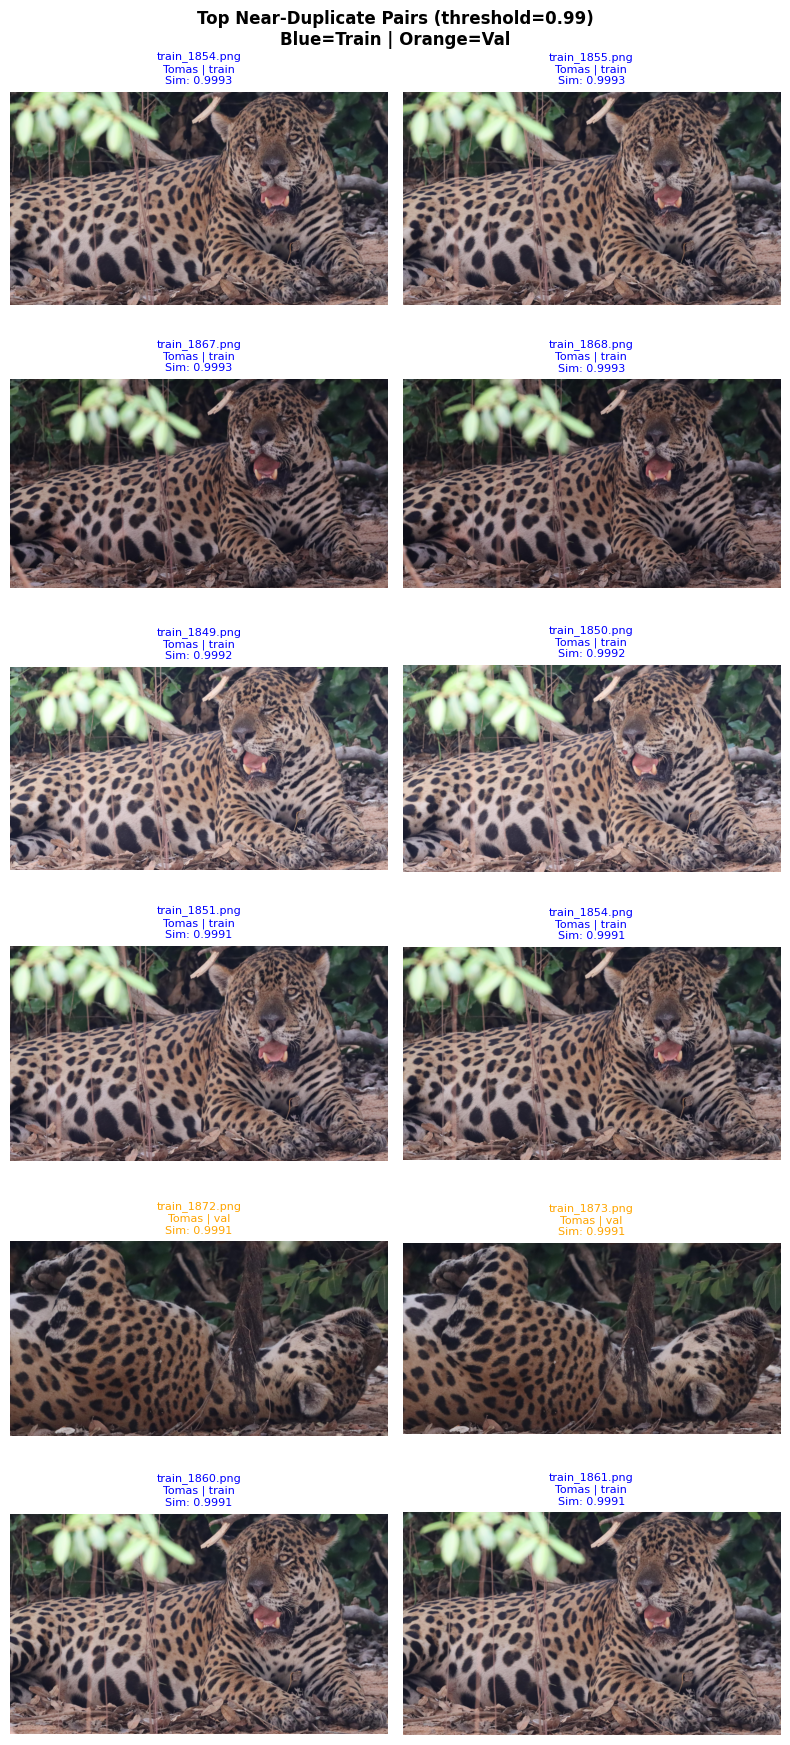

Saved: near_duplicates.png


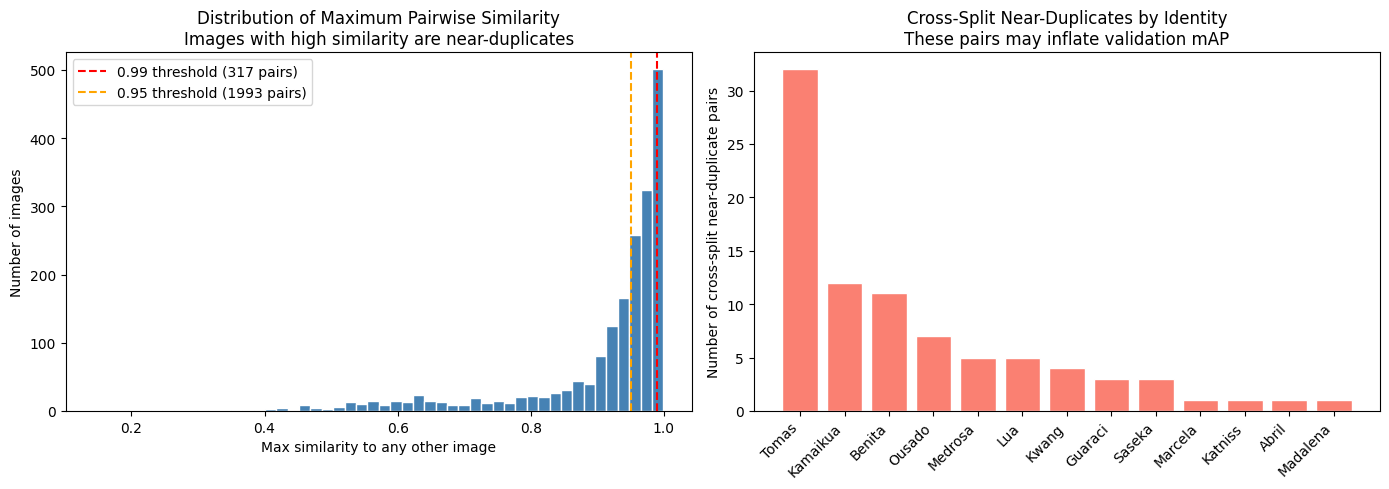

Saved: duplicate_analysis.png


In [5]:
# Per-identity duplicate analysis
print("Per-identity near-duplicate analysis (threshold=0.99):")
identity_dupes = []
for identity in sorted(train_df['ground_truth'].unique()):
    identity_pairs = pairs_df[pairs_df['label1'] == identity]
    total_images = len(train_df[train_df['ground_truth'] == identity])
    cross_split_pairs = len(identity_pairs[identity_pairs['cross_split']])
    total_pairs = len(identity_pairs)
    identity_dupes.append({
        "identity": identity,
        "total_images": total_images,
        "duplicate_pairs": total_pairs,
        "cross_split_pairs": cross_split_pairs,
        "duplicate_rate": round(total_pairs / max(total_images, 1), 2)
    })

dupes_df = pd.DataFrame(identity_dupes)
dupes_df = dupes_df[dupes_df['duplicate_pairs'] > 0].sort_values(
    'duplicate_pairs', ascending=False)
print(dupes_df.to_string(index=False))

# Visualize top near-duplicate pairs
print("\nVisualizing top near-duplicate pairs...")
n_show = 6
fig, axes = plt.subplots(n_show, 2, figsize=(8, 3*n_show))

for i, (_, row) in enumerate(pairs_df.head(n_show).iterrows()):
    for j, (img_name, split) in enumerate([
        (row['img1'], row['split1']),
        (row['img2'], row['split2'])
    ]):
        ax = axes[i][j]
        try:
            img = Image.open(
                config["data_dir"] / "train/train" / img_name
            ).convert("RGB")
            ax.imshow(img)
        except:
            ax.imshow(np.zeros((100, 100, 3)))
        
        color = 'blue' if split == 'train' else 'orange'
        label = f"{img_name}\n{row['label1']} | {split}\nSim: {row['similarity']:.4f}"
        ax.set_title(label, fontsize=8, color=color)
        ax.axis('off')
        
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
            spine.set_visible(True)

plt.suptitle(
    "Top Near-Duplicate Pairs (threshold=0.99)\nBlue=Train | Orange=Val",
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("near_duplicates.png", dpi=100, bbox_inches='tight')
plt.show()
print("Saved: near_duplicates.png")

# Similarity distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of max similarity per image
max_sims = []
for i in range(len(all_filenames)):
    sims = sim_matrix[i].copy()
    sims[i] = 0
    max_sims.append(sims.max())

axes[0].hist(max_sims, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=0.99, color='red', linestyle='--', 
                label='0.99 threshold (317 pairs)')
axes[0].axvline(x=0.95, color='orange', linestyle='--',
                label='0.95 threshold (1993 pairs)')
axes[0].set_xlabel("Max similarity to any other image")
axes[0].set_ylabel("Number of images")
axes[0].set_title("Distribution of Maximum Pairwise Similarity\n"
                  "Images with high similarity are near-duplicates")
axes[0].legend()

# Cross-split pairs per identity
cross_split_df = dupes_df[dupes_df['cross_split_pairs'] > 0].sort_values(
    'cross_split_pairs', ascending=False)
axes[1].bar(range(len(cross_split_df)), 
            cross_split_df['cross_split_pairs'],
            color='salmon', edgecolor='white')
axes[1].set_xticks(range(len(cross_split_df)))
axes[1].set_xticklabels(cross_split_df['identity'], rotation=45, ha='right')
axes[1].set_ylabel("Number of cross-split near-duplicate pairs")
axes[1].set_title("Cross-Split Near-Duplicates by Identity\n"
                  "These pairs may inflate validation mAP")

plt.tight_layout()
plt.savefig("duplicate_analysis.png", dpi=100, bbox_inches='tight')
plt.show()
print("Saved: duplicate_analysis.png")

In [6]:
wandb.login(key=os.environ["WANDB_API_KEY"])
wandb.init(
    project="jaguar-reid-mishank",
    name="exp07-near-duplicate-analysis",
    config={
        "total_images": len(train_df),
        "num_identities": num_classes,
        "threshold_99": 0.99,
        "threshold_98": 0.98,
        "threshold_97": 0.97,
        "threshold_95": 0.95,
    }
)

# Log threshold summary
wandb.log({
    "threshold_99/total_pairs": 317,
    "threshold_99/same_identity_pairs": 317,
    "threshold_99/cross_identity_pairs": 0,
    "threshold_99/cross_split_pairs": 86,
    "threshold_95/total_pairs": 1993,
    "threshold_95/same_identity_pairs": 1901,
    "threshold_95/cross_identity_pairs": 92,
    "threshold_95/cross_split_pairs": 661,
})

# Log tables
wandb.log({
    "threshold_summary": wandb.Table(
        dataframe=pd.DataFrame(threshold_results)),
    "per_identity_duplicates": wandb.Table(
        dataframe=dupes_df),
    "top_duplicate_pairs": wandb.Table(
        dataframe=pairs_df.head(50)),
})

# Log visualizations
wandb.log({
    "near_duplicate_pairs": wandb.Image("near_duplicates.png"),
    "duplicate_analysis": wandb.Image("duplicate_analysis.png"),
})

wandb.finish()
print("Logged to W&B successfully")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jain5 (jain5-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


threshold_95/cross_identity_pairs,▁
threshold_95/cross_split_pairs,▁
threshold_95/same_identity_pairs,▁
threshold_95/total_pairs,▁
threshold_99/cross_identity_pairs,▁
threshold_99/cross_split_pairs,▁
threshold_99/same_identity_pairs,▁
threshold_99/total_pairs,▁
threshold_95/cross_identity_pairs,92
threshold_95/cross_split_pairs,661
threshold_95/same_identity_pairs,1901


Logged to W&B successfully
